# Análise de Latência — Experimento 1 (Oráculo Agêntico)

Consolidação de **5 rodadas** do pipeline completo (CSV → blockchain) sobre o
conjunto de dados reais. O foco é a **latência fim-a-fim** e sua decomposição por
fase (Sensor, Validator, Governance, Blockchain), com análise estatística.

As decisões do sistema são determinísticas (idênticas entre rodadas), portanto as
repetições servem para caracterizar a **variabilidade de desempenho**, não de decisão.

Cada gráfico é salvo em `results/analise_latencia/` em alta resolução para uso na
dissertação.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo de publicação
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
})

RESULTS = Path("results")
OUT = RESULTS / "analise_latencia"
OUT.mkdir(parents=True, exist_ok=True)

PHASES = ["sensor", "validator", "governance", "blockchain"]
LAT_COLS = [f"lat_{p}_s" for p in PHASES]
PHASE_LABEL = {"sensor": "Sensor", "validator": "Validator",
               "governance": "Governance", "blockchain": "Blockchain"}


## 1. Carregamento dos dados

In [2]:
def load_latency(results_dir=RESULTS, pattern="rodada_*"):
    manifests = sorted(results_dir.glob(f"{pattern}/**/_manifest.json"))
    rows = []
    for m in manifests:
        d = json.loads(m.read_text(encoding="utf-8"))
        run = m.relative_to(results_dir).parts[0]
        # rótulo curto: rodada_N
        short = run.split("_run_")[0] if "_run_" in run else run
        for s in d.get("sessions", []):
            if s.get("status") != "ok" or s.get("lat_blockchain_s") is None:
                continue
            rows.append({
                "run": short,
                "vehicle": s.get("vehicle"),
                "viagem": s.get("viagem"),
                "scenario": s.get("scenario"),
                "decision": s.get("governance_decision"),
                "distance_km": s.get("distance_km"),
                "elapsed_s": s.get("elapsed_s"),
                **{p: s.get(f"lat_{p}_s") for p in PHASES},
            })
    df = pd.DataFrame(rows)
    # tempo agêntico (3 fases LLM) vs blockchain
    df["agentico_s"] = df[["sensor", "validator", "governance"]].sum(axis=1)
    df["pipeline_s"] = df[PHASES].sum(axis=1)
    return df

df = load_latency()
print(f"Rodadas: {sorted(df['run'].unique())}")
print(f"Sessões com latência: {len(df)}")
df.head()


Rodadas: ['rodada_1', 'rodada_2', 'rodada_3', 'rodada_4', 'rodada_5']
Sessões com latência: 360


,run,vehicle,viagem,scenario,decision,distance_km,elapsed_s,sensor,validator,governance,blockchain,agentico_s,pipeline_s
0,rodada_1,creta,1,01_viagem_perfeita,approved,5.558,34.06,5.004,3.028,3.502,17.966,11.534,29.500
1,rodada_1,creta,1,02_eco_motorista,approved,9.847,33.17,3.435,3.280,3.445,19.095,10.160,29.255
2,rodada_1,creta,1,03_viagem_etanol,approved,5.558,33.20,3.461,3.063,3.432,19.131,9.956,29.087
3,rodada_1,creta,1,04_falha_sensor_maf_mas_valido,approved,5.558,33.13,3.457,3.266,3.454,18.932,10.177,29.109
4,rodada_1,creta,1,05_motorista_agressivo,approved,19.781,33.20,3.411,3.113,3.232,18.971,9.756,28.727


## 2. Estatística descritiva por fase

Média, desvio-padrão, mediana, percentil 95 e coeficiente de variação (CV = desvio/média).
O CV mede a estabilidade relativa de cada fase.


In [3]:
def describe_phase(df):
    recs = []
    for p in PHASES + ["agentico", "pipeline"]:
        col = p if p in ("agentico", "pipeline") else p
        col = {"agentico": "agentico_s", "pipeline": "pipeline_s"}.get(p, p)
        x = df[col].dropna()
        recs.append({
            "fase": PHASE_LABEL.get(p, p.capitalize()),
            "média (s)": x.mean(),
            "desvio (s)": x.std(),
            "mediana (s)": x.median(),
            "p95 (s)": x.quantile(0.95),
            "mín (s)": x.min(),
            "máx (s)": x.max(),
            "CV (%)": 100 * x.std() / x.mean(),
        })
    return pd.DataFrame(recs).set_index("fase").round(2)

desc = describe_phase(df)
desc.to_csv(OUT / "descritiva_latencia.csv", encoding="utf-8")
desc


,média (s),desvio (s),mediana (s),p95 (s),mín (s),máx (s),CV (%)
fase,,,,,,,
Sensor,4.01,0.63,3.86,4.74,3.14,9.32,15.67
Validator,3.23,0.09,3.23,3.38,3.02,3.47,2.94
Governance,3.29,0.21,3.27,3.60,2.94,4.01,6.48
Blockchain,15.57,2.03,14.80,19.15,12.11,20.83,13.03
Agentico,10.53,0.70,10.49,11.41,9.48,16.45,6.63
Pipeline,26.10,2.20,25.22,29.87,22.82,37.29,8.42


## 3. Onde o tempo é gasto — composição do pipeline

Decomposição da latência média fim-a-fim entre as quatro fases.


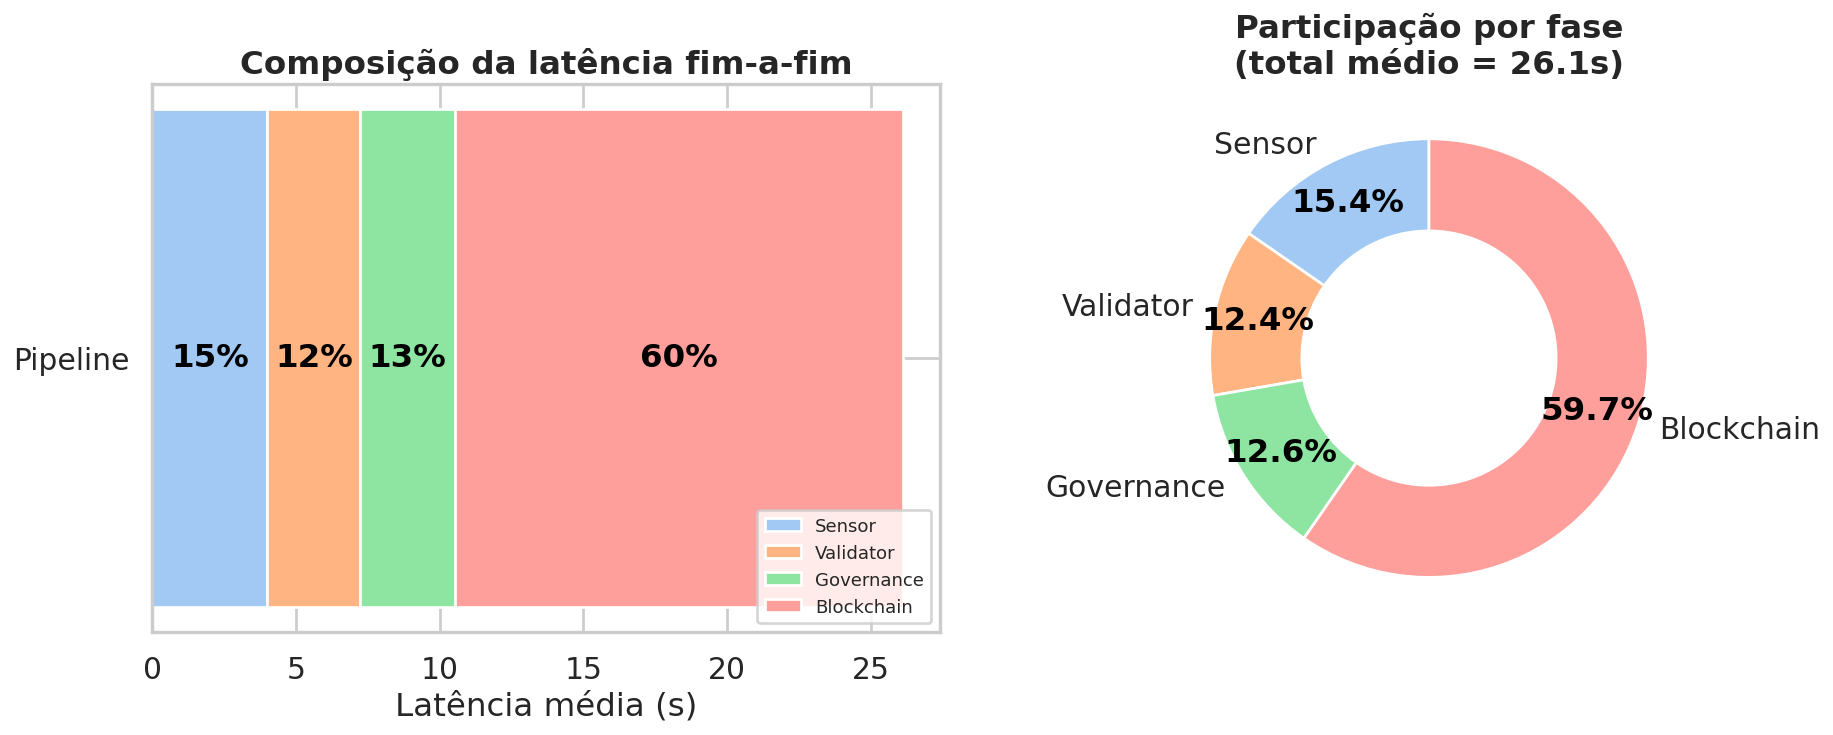

Tempo agêntico (LLM): 10.5s (40%)
Tempo blockchain    : 15.6s (60%)


In [9]:
means = df[PHASES].mean()
total = means.sum()
pct = 100 * means / total

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) barras horizontais empilhadas — composição
left = 0
colors = sns.color_palette("pastel", len(PHASES))
for p, c in zip(PHASES, colors):
    axes[0].barh(["Pipeline"], [means[p]], left=left, color=c, label=PHASE_LABEL[p])
    axes[0].text(left + means[p] / 2, 0, f"{pct[p]:.0f}%", ha="center", va="center",
                 color="black", fontweight="bold")
    left += means[p]
axes[0].set_xlabel("Latência média (s)")
axes[0].set_title("Composição da latência fim-a-fim")
axes[0].legend(loc="lower right", fontsize=10)

# (b) rosca (donut) — participação percentual
wedges, _, autotexts = axes[1].pie(
    means, labels=[PHASE_LABEL[p] for p in PHASES], autopct="%1.1f%%",
    startangle=90, colors=colors, pctdistance=0.8,
    wedgeprops=dict(width=0.42, edgecolor="white"))
for t in autotexts:
    t.set_fontweight("bold"); t.set_color("black")
axes[1].set_title(f"Participação por fase\n(total médio = {total:.1f}s)")

fig.tight_layout()
fig.savefig(OUT / "composicao_latencia.png")
plt.show()
print(f"Tempo agêntico (LLM): {means[['sensor','validator','governance']].sum():.1f}s "
      f"({100*means[['sensor','validator','governance']].sum()/total:.0f}%)")
print(f"Tempo blockchain    : {means['blockchain']:.1f}s ({pct['blockchain']:.0f}%)")


## 4. Distribuição da latência por fase

Boxplot + violino mostram dispersão, mediana e caudas de cada fase.


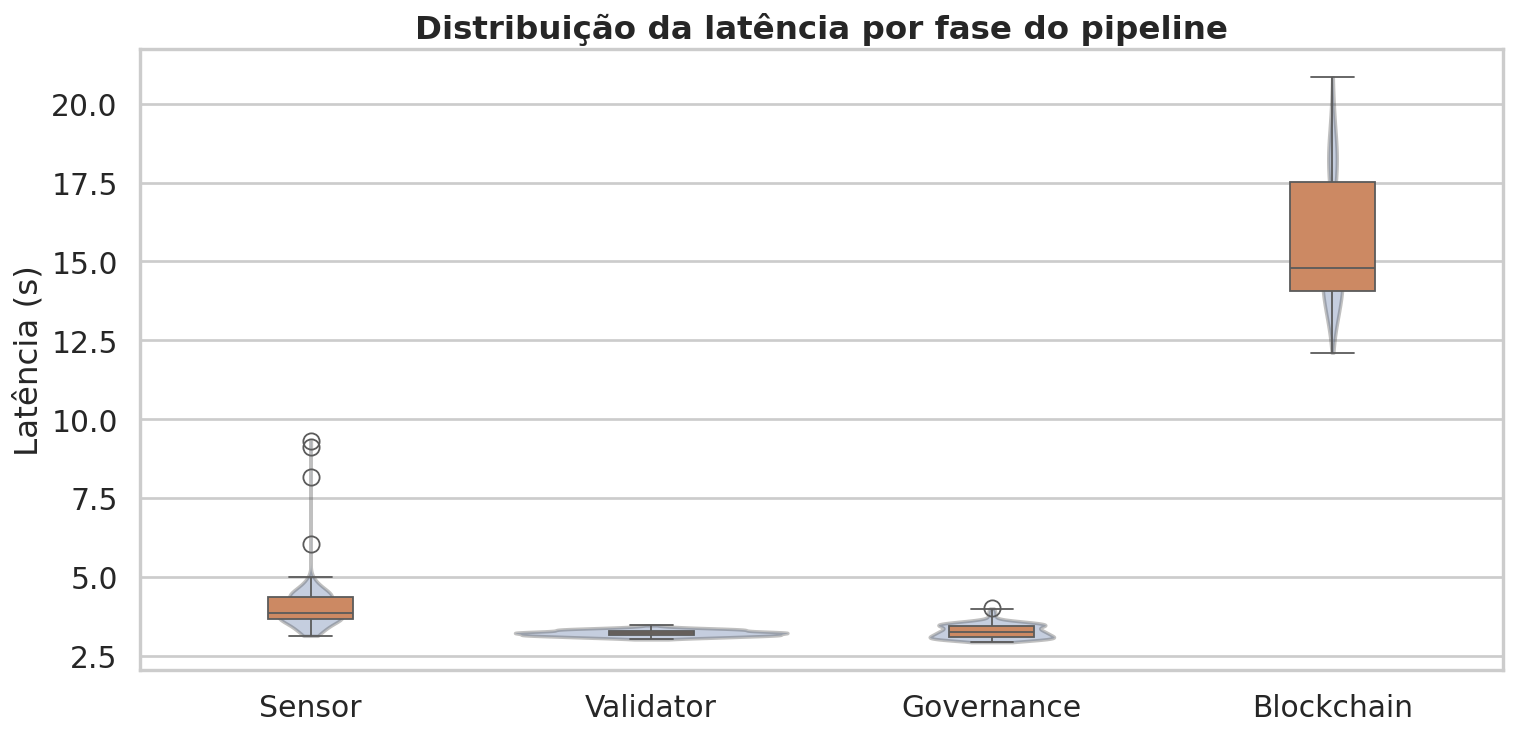

In [10]:
long = df.melt(id_vars=["run", "decision"], value_vars=PHASES,
               var_name="fase", value_name="latencia")
long["fase"] = long["fase"].map(PHASE_LABEL)
order = [PHASE_LABEL[p] for p in PHASES]

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=long, x="fase", y="latencia", order=order, inner=None,
               cut=0, alpha=0.35, ax=ax)
sns.boxplot(data=long, x="fase", y="latencia", order=order, width=0.25,
            showcaps=True, boxprops={"zorder": 2}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Latência (s)")
ax.set_title("Distribuição da latência por fase do pipeline")
fig.tight_layout()
fig.savefig(OUT / "distribuicao_fases.png")
plt.show()


## 5. Latência fim-a-fim (end-to-end)

Distribuição do tempo total por sessão (`elapsed_s`).


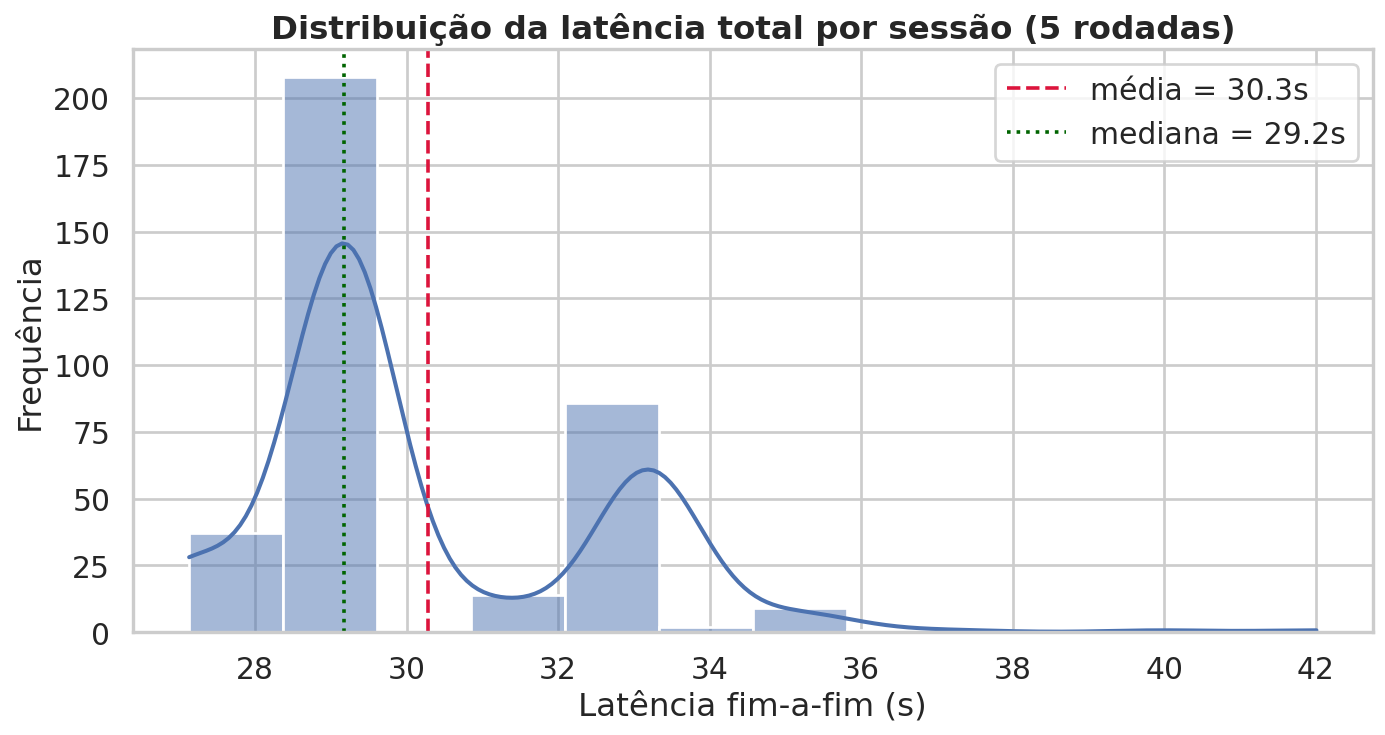

count    360.00
mean      30.28
std        2.30
min       27.13
25%       29.15
50%       29.18
75%       33.15
max       42.01
Name: elapsed_s, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(df["elapsed_s"], bins=12, kde=True, color=sns.color_palette("deep")[0], ax=ax)
ax.axvline(df["elapsed_s"].mean(), color="crimson", ls="--", lw=2,
           label=f"média = {df['elapsed_s'].mean():.1f}s")
ax.axvline(df["elapsed_s"].median(), color="darkgreen", ls=":", lw=2,
           label=f"mediana = {df['elapsed_s'].median():.1f}s")
ax.set_xlabel("Latência fim-a-fim (s)"); ax.set_ylabel("Frequência")
ax.set_title("Distribuição da latência total por sessão (5 rodadas)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "distribuicao_total.png")
plt.show()
print(df["elapsed_s"].describe().round(2))


## 6. Estabilidade do desempenho entre rodadas

As decisões são idênticas entre rodadas; aqui verificamos se o **desempenho**
(latência) também é estável. Usamos o teste de **Kruskal-Wallis** (não paramétrico)
para checar se há diferença significativa de latência total entre as 5 rodadas.


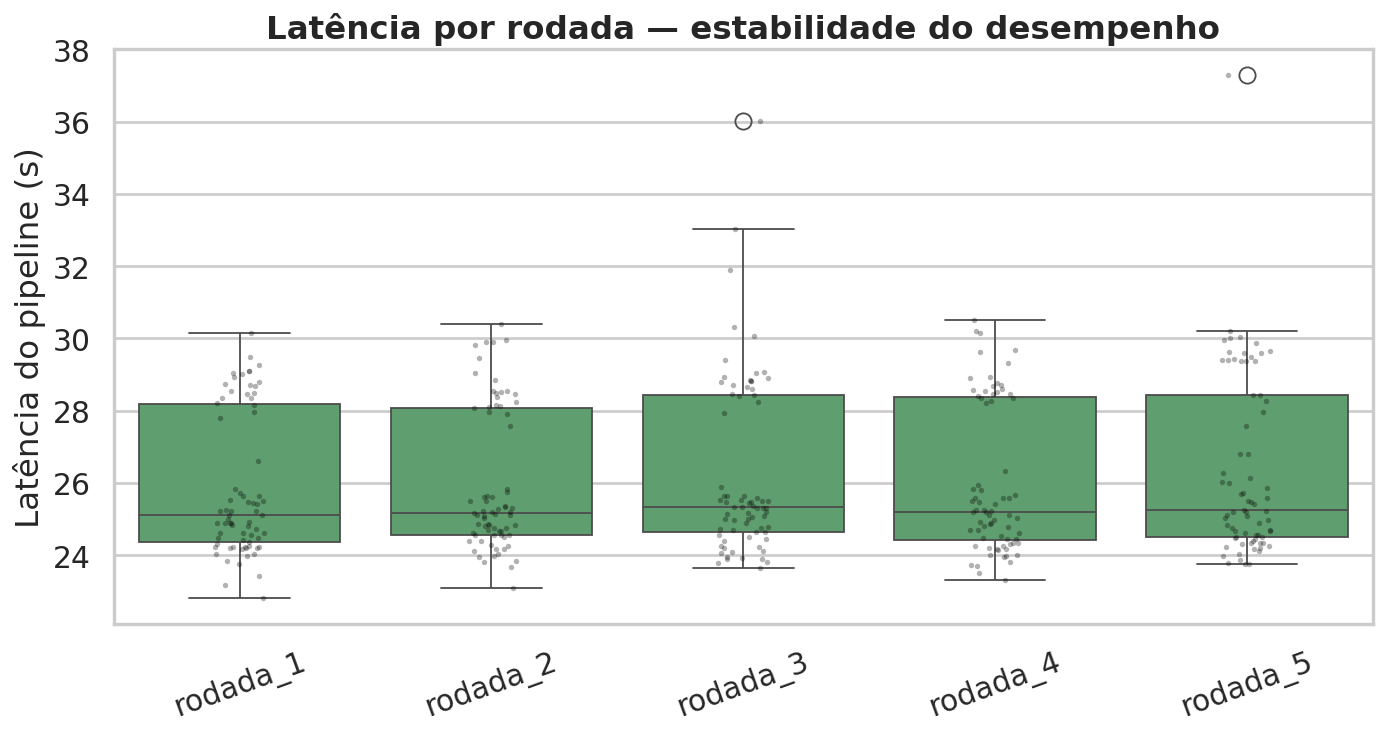

Kruskal-Wallis: H = 1.719, p = 0.7873
=> Sem diferença significativa entre rodadas (p > 0.05): desempenho estável.

Média ± desvio por rodada (s):
           mean   std
run                  
rodada_1  25.87  1.96
rodada_2  25.98  1.96
rodada_3  26.27  2.45
rodada_4  26.02  2.05
rodada_5  26.35  2.51


In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x="run", y="pipeline_s", ax=ax, color=sns.color_palette("deep")[2])
sns.stripplot(data=df, x="run", y="pipeline_s", color="black", alpha=0.3, size=3, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Latência do pipeline (s)")
ax.set_title("Latência por rodada — estabilidade do desempenho")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(OUT / "estabilidade_rodadas.png")
plt.show()

groups = [g["pipeline_s"].values for _, g in df.groupby("run")]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {H:.3f}, p = {p:.4f}")
print("=> Sem diferença significativa entre rodadas (p > 0.05): desempenho estável."
      if p > 0.05 else
      "=> Há diferença significativa entre rodadas (p <= 0.05).")
print("\nMédia ± desvio por rodada (s):")
print(df.groupby("run")["pipeline_s"].agg(["mean", "std"]).round(2))


## 7. Custo da cunhagem do certificado (aprovado vs. negado)

Sessões **aprovadas** executam 4 transações on-chain (log, validate, governance,
**mint do NFT**); sessões **negadas** executam 3 (sem mint). Comparamos a latência
da fase *blockchain* entre os dois grupos com o teste de **Mann-Whitney U**.


C:\Users\FUNPEC\AppData\Local\Temp\ipykernel_26076\2639399528.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"Negado (3 tx)\nn={len(deny)}", f"Aprovado (4 tx + mint)\nn={len(appr)}"])


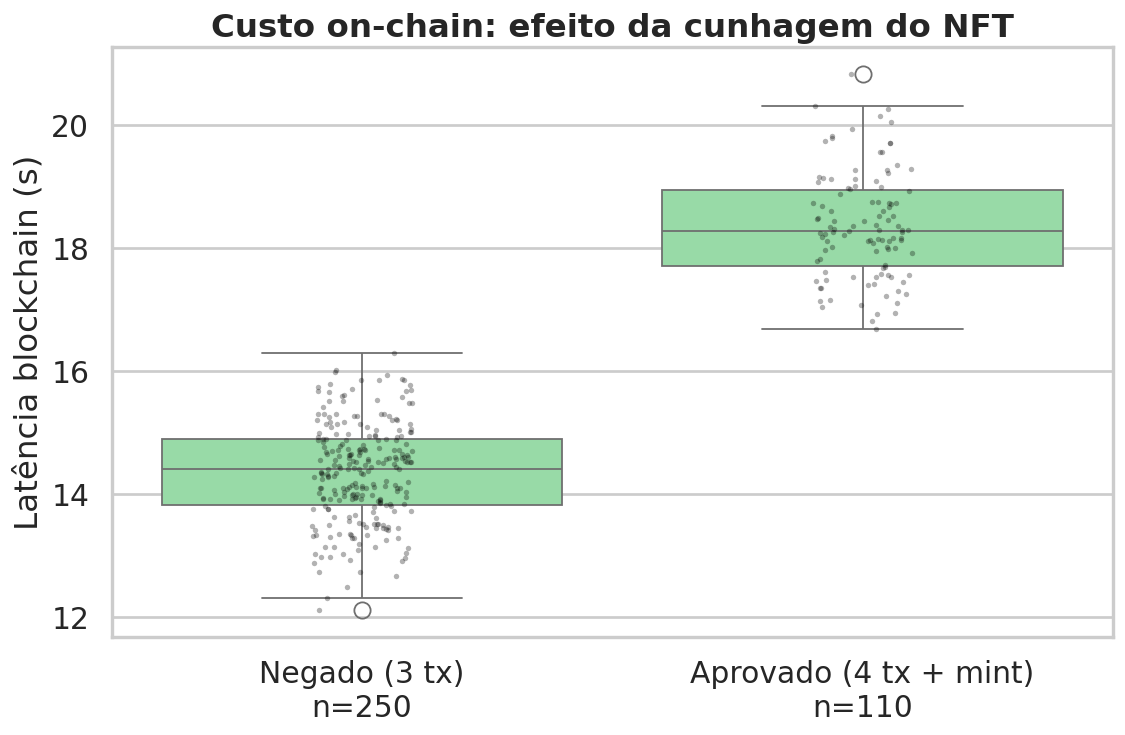

Negado  : 14.34 ± 0.80 s (n=250)
Aprovado: 18.36 ± 0.86 s (n=110)
Diferença (custo do mint): 4.02 s
Mann-Whitney U = 27500, p = 6.281e-52
=> Aprovadas são significativamente mais lentas (mint adiciona custo).


In [17]:
appr = df[df["decision"] == "approved"]["blockchain"]
deny = df[df["decision"] == "denied"]["blockchain"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x="decision", y="blockchain",
            order=["denied", "approved"], ax=ax, color=sns.color_palette("pastel")[2])
sns.stripplot(data=df, x="decision", y="blockchain",
              order=["denied", "approved"], color="black", alpha=0.3, size=3, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Latência blockchain (s)")
ax.set_xticklabels([f"Negado (3 tx)\nn={len(deny)}", f"Aprovado (4 tx + mint)\nn={len(appr)}"])
ax.set_title("Custo on-chain: efeito da cunhagem do NFT")
fig.tight_layout()
fig.savefig(OUT / "custo_mint.png")
plt.show()

U, p = stats.mannwhitneyu(appr, deny, alternative="greater")
delta = appr.mean() - deny.mean()
print(f"Negado  : {deny.mean():.2f} ± {deny.std():.2f} s (n={len(deny)})")
print(f"Aprovado: {appr.mean():.2f} ± {appr.std():.2f} s (n={len(appr)})")
print(f"Diferença (custo do mint): {delta:.2f} s")
print(f"Mann-Whitney U = {U:.0f}, p = {p:.3e}")
print("=> Aprovadas são significativamente mais lentas (mint adiciona custo)."
      if p < 0.05 else "=> Sem diferença significativa.")


## 8. Correlação entre as fases

Verifica se as fases variam juntas (ex.: rodadas mais lentas afetam tudo) ou de
forma independente.


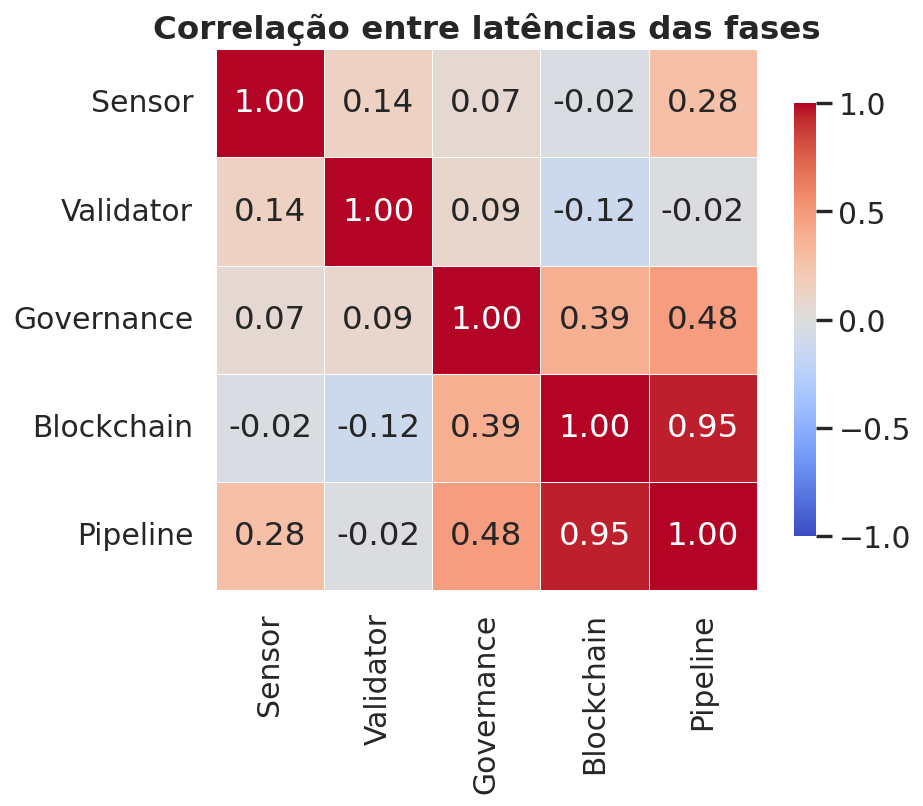

In [21]:
corr = df[PHASES + ["pipeline_s"]].rename(
    columns={**PHASE_LABEL, "pipeline_s": "Pipeline"}).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlação entre latências das fases")
fig.tight_layout()
fig.savefig(OUT / "correlacao_fases.png")
plt.show()


## 9. Síntese dos achados

In [22]:
m = df[PHASES].mean()
tot = m.sum()
print("=" * 60)
print("SÍNTESE — LATÊNCIA DO EXPERIMENTO 1 (5 rodadas, n={} sessões)".format(len(df)))
print("=" * 60)
print(f"Latência fim-a-fim média : {df['elapsed_s'].mean():.1f} s "
      f"(mediana {df['elapsed_s'].median():.1f}, p95 {df['elapsed_s'].quantile(.95):.1f})")
print(f"Fase dominante           : Blockchain ({100*m['blockchain']/tot:.0f}% do tempo)")
print(f"Tempo agêntico (3 LLMs)  : {m[['sensor','validator','governance']].sum():.1f} s "
      f"({100*m[['sensor','validator','governance']].sum()/tot:.0f}%)")
print(f"Custo da cunhagem (mint) : +{appr.mean()-deny.mean():.1f} s nas sessões aprovadas")
print(f"Estabilidade entre rodadas: CV do pipeline = "
      f"{100*df['pipeline_s'].std()/df['pipeline_s'].mean():.1f}%")
print("\nArtefatos salvos em:", OUT.resolve())


SÍNTESE — LATÊNCIA DO EXPERIMENTO 1 (5 rodadas, n=360 sessões)
Latência fim-a-fim média : 30.3 s (mediana 29.2, p95 33.2)
Fase dominante           : Blockchain (60% do tempo)
Tempo agêntico (3 LLMs)  : 10.5 s (40%)
Custo da cunhagem (mint) : +4.0 s nas sessões aprovadas
Estabilidade entre rodadas: CV do pipeline = 8.4%

Artefatos salvos em: C:\Users\FUNPEC\Documents\GitHub\carbon-mas-v2\results\analise_latencia
